<a href="https://colab.research.google.com/github/miftahulhdd/MiftahulHudaAmri_2411533005_ML2526/blob/main/praktikum7/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [8]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

model tanpa batas depth

In [9]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)
y_train_pred = tree_default.predict(X_train)
y_test_pred = tree_default.predict(X_test)
print("Train Accuracy", accuracy_score(y_train, y_train_pred))
print("Test Accuracy", accuracy_score(y_test, y_test_pred))

Train Accuracy 1.0
Test Accuracy 0.9473684210526315


tree depth tuning

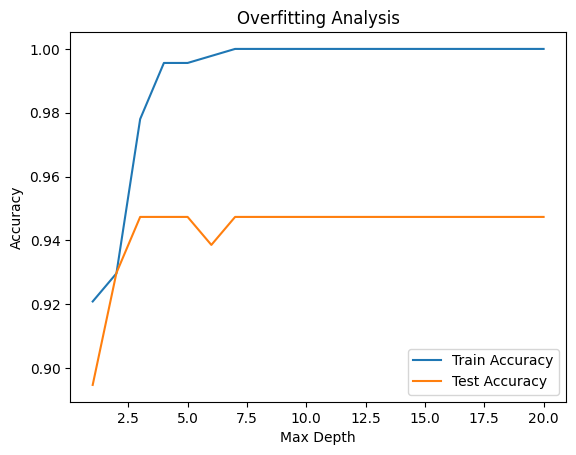

In [10]:
depths = range(1, 21)
train_acc = []
test_acc = []
for d in depths:
  model = DecisionTreeClassifier(max_depth=d, random_state=42)
  model.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, model.predict(X_train)))
  test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting Analysis")
plt.show()

gini vs entropy

In [11]:
tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
tree_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

acc_gini = accuracy_score(y_test, tree_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, tree_entropy.predict(X_test))
print("Accuracy (Gini):", acc_gini)
print("Accuracy (Entropy):", acc_entropy)

Accuracy (Gini): 0.9473684210526315
Accuracy (Entropy): 0.9473684210526315


visualisasi tree

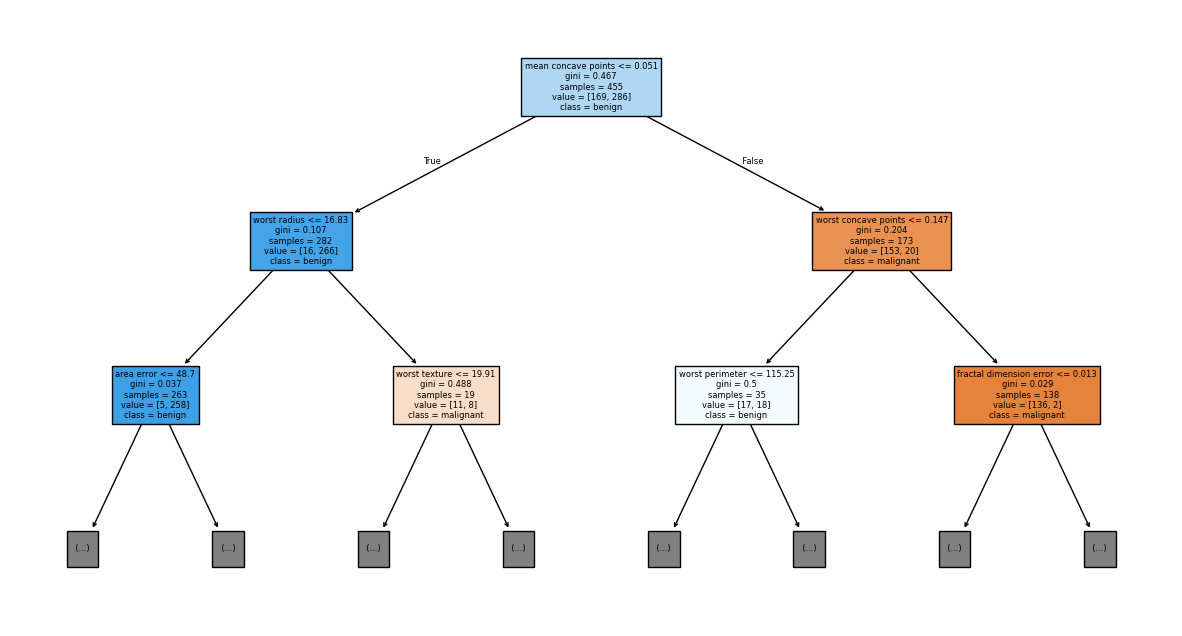

In [12]:
plt.figure(figsize=(15,8))
plot_tree(
  tree_gini,
  feature_names=X.columns,
  class_names=data.target_names,
  filled=True,
  max_depth=2
)
plt.show()